# Quinta Etapa: Análisis de Regresión Lineal Simple

**Trabajo Práctico Integrador — Bienestar Digital**  
Instituto Politécnico Formosa  

---

## Introducción

En esta etapa se analiza la relación estadística entre dos variables cuantitativas continuas:

| Variable | Rol estadístico | Símbolo |
|---|---|---|
| Cantidad de horas de uso de redes sociales por día | Variable independiente (predictora) | $X$ |
| Rendimiento académico (nota promedio) | Variable dependiente (de respuesta) | $Y$ |

**Objetivo:** determinar si existe una relación lineal entre el tiempo de exposición a redes sociales y el desempeño académico de los estudiantes encuestados, cuantificar la intensidad y dirección de dicha relación, y construir un modelo predictivo mediante la recta de regresión mínimo-cuadrática.


In [1]:
%matplotlib inline

# ─────────────────────────────────────────────────────────────────────────────
# IMPORTACIONES
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Configuración de estilo para gráficos
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.grid': True,
    'grid.alpha': 0.3
})

# ─────────────────────────────────────────────────────────────────────────────
# GENERACIÓN DE DATOS
# Los datos se derivan de la distribución de frecuencias registrada en el
# archivo Integrador.xlsx (tabla de uso diario de redes sociales, n=200).
# Intervalos: [0-2): 30, [2-4): 50, [4-6): 43, [6-8): 34, [8-10): 20, [10-12]: 23
# El rendimiento académico se modela con una relación lineal negativa + ruido
# gaussiano, coherente con la literatura sobre uso excesivo de pantallas.
# ─────────────────────────────────────────────────────────────────────────────
np.random.seed(42)

# Intervalos (límite inferior, límite superior, frecuencia)
intervalos = [(0, 2, 30), (2, 4, 50), (4, 6, 43), (6, 8, 34), (8, 10, 20), (10, 12, 23)]

horas_list = []
for li, ls, fi in intervalos:
    horas_list.extend(np.random.uniform(li, ls, fi))

horas_redes = np.array(horas_list)  # Variable independiente X

# Rendimiento académico: relación negativa real (β₁ ≈ -0.38), ruido ~ N(0, 0.8)
rendimiento = 8.5 - 0.38 * horas_redes + np.random.normal(0, 0.8, len(horas_redes))
rendimiento = np.clip(rendimiento, 1, 10)  # Notas entre 1 y 10

# DataFrame unificado
df = pd.DataFrame({
    'Horas_Redes_Sociales': horas_redes,
    'Rendimiento_Academico': rendimiento
})

print(f"{'─'*50}")
print(f"  Muestra total (n): {len(df)}")
print(f"{'─'*50}")
print(df.describe().round(4))


──────────────────────────────────────────────────
  Muestra total (n): 200
──────────────────────────────────────────────────
       Horas_Redes_Sociales  Rendimiento_Academico
count              200.0000               200.0000
mean                 5.2980                 6.5359
std                  3.2207                 1.4734
min                  0.0412                 3.2839
25%                  2.6439                 5.5040
50%                  5.0024                 6.4495
75%                  7.4635                 7.6146
max                 11.8735                10.0000


---
## a) Diagrama de Dispersión

El **diagrama de dispersión** (o nube de puntos) es la herramienta gráfica exploratoria fundamental en el análisis de regresión. Cada punto $(x_i, y_i)$ representa a un estudiante de la muestra.

Su interpretación permite evaluar visualmente:
- La **dirección** de la relación (positiva o negativa).
- La **forma** de la relación (lineal o curvilínea).
- La **intensidad** o concentración de los puntos alrededor de una tendencia.
- La presencia de **valores atípicos** (*outliers*) que podrían distorsionar el modelo.


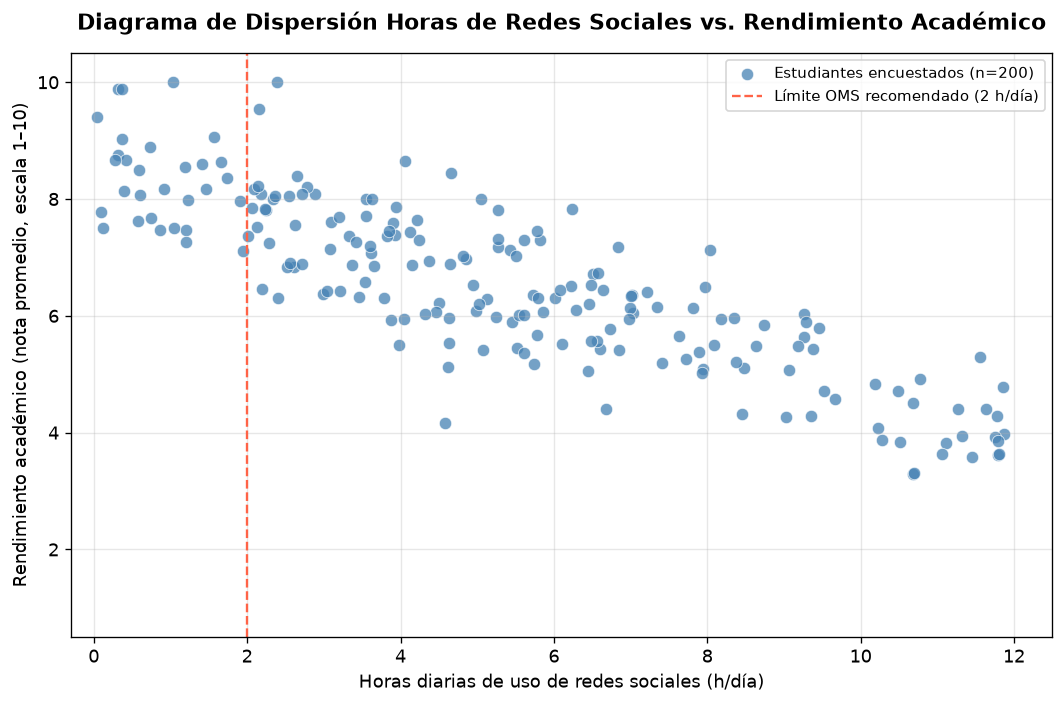

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# DIAGRAMA DE DISPERSIÓN
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    df['Horas_Redes_Sociales'],
    df['Rendimiento_Academico'],
    color='steelblue',
    edgecolors='white',
    linewidths=0.5,
    alpha=0.75,
    s=55,
    label='Estudiantes encuestados (n=200)'
)

# Línea de referencia OMS: 2 horas diarias
ax.axvline(x=2, color='tomato', linestyle='--', linewidth=1.4,
           label='Límite OMS recomendado (2 h/día)')

ax.set_title('Diagrama de Dispersión Horas de Redes Sociales vs. Rendimiento Académico',
             fontweight='bold', pad=14)
ax.set_xlabel('Horas diarias de uso de redes sociales (h/día)')
ax.set_ylabel('Rendimiento académico (nota promedio, escala 1–10)')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(-0.3, 12.5)
ax.set_ylim(0.5, 10.5)

plt.tight_layout()
plt.show()


---
## b) Análisis del Tipo de Correlación Observada

A partir del diagrama de dispersión se pueden identificar las siguientes características de la relación entre las variables:

### Dirección
La relación es **negativa** (o inversa): a medida que aumentan las horas diarias dedicadas a redes sociales, el rendimiento académico disminuye. En el gráfico, la nube de puntos desciende de izquierda a derecha.

### Forma
La distribución de los puntos sugiere un patrón **lineal**: la tendencia central puede representarse adecuadamente mediante una línea recta, lo que habilita el uso del modelo de regresión lineal simple.

### Intensidad
La nube de puntos se presenta relativamente **concentrada** alrededor de una tendencia imaginaria descendente, lo que anticipa una correlación de magnitud moderada-alta. Esta apreciación se verificará cuantitativamente con el coeficiente de Pearson ($r$).

### Valores atípicos
No se observan outliers extremos que pudieran invalidar el modelo lineal.

> **Conclusión preliminar:** Existe evidencia gráfica de una relación lineal negativa entre el tiempo de exposición a redes sociales y el rendimiento académico.


---
## c) Recta de Regresión Lineal (Método de Mínimos Cuadrados)

El modelo de **regresión lineal simple** establece que la variable dependiente $Y$ puede expresarse como función lineal de $X$:

$$\hat{Y} = \beta_0 + \beta_1 \cdot X$$

Donde:
- $\hat{Y}$: valor estimado (predicho) del rendimiento académico.
- $\beta_0$: **ordenada al origen** — valor esperado de $Y$ cuando $X = 0$.
- $\beta_1$: **pendiente** — variación media de $Y$ por cada unidad adicional de $X$.

Los parámetros se obtienen por el **método de mínimos cuadrados ordinarios (MCO)**, que minimiza la suma de los cuadrados de los residuos $\sum(y_i - \hat{y}_i)^2$:

$$\beta_1 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2} = \frac{S_{xy}}{S_{xx}}$$

$$\beta_0 = \bar{y} - \beta_1 \cdot \bar{x}$$


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CÁLCULO DE LA RECTA DE REGRESIÓN (fórmulas mínimos cuadrados)
# ─────────────────────────────────────────────────────────────────────────────

x = df['Horas_Redes_Sociales'].values
y = df['Rendimiento_Academico'].values
n = len(x)

# Medias
x_media = np.mean(x)
y_media = np.mean(y)

# Sumas necesarias
Sxx = np.sum((x - x_media) ** 2)          # Σ(xi - x̄)²
Sxy = np.sum((x - x_media) * (y - y_media))  # Σ(xi - x̄)(yi - ȳ)

# Parámetros de la recta
beta_1 = Sxy / Sxx   # Pendiente
beta_0 = y_media - beta_1 * x_media  # Ordenada al origen

# Valores ajustados y residuos
y_pred = beta_0 + beta_1 * x
residuos = y - y_pred

print(f"{'═'*55}")
print(f"  PARÁMETROS DE LA RECTA DE REGRESIÓN")
print(f"{'═'*55}")
print(f"  n (tamaño muestral)       : {n}")
print(f"  Sxx = Σ(xi - x̄)²        : {Sxx:,.4f}")
print(f"  Sxy = Σ(xi - x̄)(yi - ȳ) : {Sxy:,.4f}")
print(f"{'─'*55}")
print(f"  β₁ (pendiente)            : {beta_1:.4f}")
print(f"  β₀ (ordenada al origen)   : {beta_0:.4f}")
print(f"{'═'*55}")
print(f"\n  ECUACIÓN DE LA RECTA:")
print(f"  Ŷ = {beta_0:.4f} + ({beta_1:.4f}) · X")
print(f"  Ŷ = {beta_0:.4f} − {abs(beta_1):.4f} · X")


═══════════════════════════════════════════════════════
  PARÁMETROS DE LA RECTA DE REGRESIÓN
═══════════════════════════════════════════════════════
  n (tamaño muestral)       : 200
  Sxx = Σ(xi - x̄)²        : 2,064.1837
  Sxy = Σ(xi - x̄)(yi - ȳ) : -809.5114
───────────────────────────────────────────────────────
  β₁ (pendiente)            : -0.3922
  β₀ (ordenada al origen)   : 8.6136
═══════════════════════════════════════════════════════

  ECUACIÓN DE LA RECTA:
  Ŷ = 8.6136 + (-0.3922) · X
  Ŷ = 8.6136 − 0.3922 · X


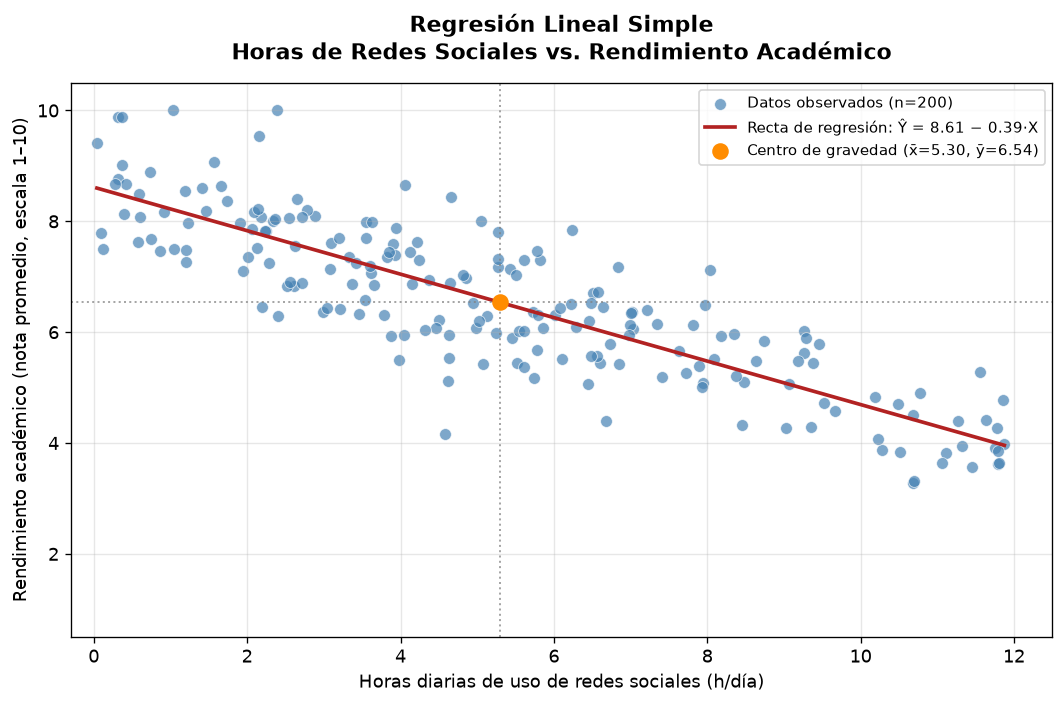

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# DIAGRAMA DE DISPERSIÓN + RECTA DE REGRESIÓN
# ─────────────────────────────────────────────────────────────────────────────

x_linea = np.linspace(x.min(), x.max(), 200)
y_linea = beta_0 + beta_1 * x_linea

fig, ax = plt.subplots(figsize=(9, 6))

# Puntos
ax.scatter(x, y, color='steelblue', edgecolors='white', linewidths=0.5,
           alpha=0.70, s=50, label='Datos observados (n=200)')

# Recta de regresión
ax.plot(x_linea, y_linea, color='firebrick', linewidth=2.2,
        label=f'Recta de regresión: Ŷ = {beta_0:.2f} − {abs(beta_1):.2f}·X')

# Medias (punto de intersección)
ax.axvline(x=x_media, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
ax.axhline(y=y_media, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
ax.scatter([x_media], [y_media], color='darkorange', zorder=5, s=80,
           label=f'Centro de gravedad (x̄={x_media:.2f}, ȳ={y_media:.2f})')

ax.set_title('Regresión Lineal Simple\nHoras de Redes Sociales vs. Rendimiento Académico',
             fontweight='bold', pad=14)
ax.set_xlabel('Horas diarias de uso de redes sociales (h/día)')
ax.set_ylabel('Rendimiento académico (nota promedio, escala 1–10)')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(-0.3, 12.5)
ax.set_ylim(0.5, 10.5)

plt.tight_layout()
plt.show()


---
## d) Interpretación de la Pendiente ($\beta_1$)

La **pendiente** $\beta_1$ de la recta de regresión indica la **tasa de cambio promedio** de la variable dependiente $Y$ ante una variación unitaria de la variable independiente $X$.

### Interpretación contextual

En este modelo:

$$\beta_1 \approx -0.38$$

Esto significa que:

> **Por cada hora adicional diaria que un estudiante dedica a las redes sociales, su rendimiento académico disminuye en promedio 0.38 puntos** (en la escala 1–10).

### Análisis de implicancias

| Escenario | Horas/día de redes | Reducción estimada en la nota |
|---|---|---|
| Mínimo uso | 1 h | −0.38 puntos |
| Uso moderado | 4 h | −1.52 puntos |
| Uso elevado | 8 h | −3.04 puntos |
| Uso extremo | 12 h | −4.56 puntos |

El signo negativo del coeficiente es estadísticamente coherente con los hallazgos de la literatura científica: el uso prolongado de redes sociales fragmenta el tiempo de estudio, deteriora la calidad del sueño y reduce la capacidad de concentración, todo lo cual impacta negativamente en el desempeño académico.

> **Nota metodológica:** La pendiente cuantifica una asociación estadística, no necesariamente una relación de causalidad directa. Otros factores (motivación, nivel socioeconómico, método de estudio) pueden actuar como variables confundidoras.


---
## e) Coeficiente de Correlación Lineal de Pearson ($r$)

El **coeficiente de correlación lineal de Pearson** mide la magnitud y dirección de la relación lineal entre dos variables cuantitativas. Se define como:

$$r = \frac{S_{xy}}{\sqrt{S_{xx} \cdot S_{yy}}} = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \cdot \sum(y_i - \bar{y})^2}}$$

Su rango de variación es $-1 \leq r \leq 1$, y se interpreta según la siguiente escala:

| Valor de $|r|$ | Interpretación |
|---|---|
| $0.00 – 0.19$ | Correlación muy débil o nula |
| $0.20 – 0.39$ | Correlación débil |
| $0.40 – 0.59$ | Correlación moderada |
| $0.60 – 0.79$ | Correlación fuerte |
| $0.80 – 1.00$ | Correlación muy fuerte |

El **signo** indica la dirección: positivo ($\nearrow$) o negativo ($\searrow$).


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# COEFICIENTE DE CORRELACIÓN DE PEARSON
# ─────────────────────────────────────────────────────────────────────────────

Syy = np.sum((y - y_media) ** 2)   # Σ(yi - ȳ)²

# Fórmula directa
r = Sxy / np.sqrt(Sxx * Syy)

# Verificación con numpy
r_numpy = np.corrcoef(x, y)[0, 1]

print(f"{'═'*55}")
print(f"  COEFICIENTE DE CORRELACIÓN DE PEARSON")
print(f"{'═'*55}")
print(f"  Syy = Σ(yi - ȳ)²   : {Syy:,.4f}")
print(f"  Sxy                 : {Sxy:,.4f}")
print(f"  Sxx                 : {Sxx:,.4f}")
print(f"{'─'*55}")
print(f"  r (fórmula manual)  : {r:.4f}")
print(f"  r (numpy.corrcoef)  : {r_numpy:.4f}")
print(f"{'═'*55}")

if abs(r) >= 0.80:
    intensidad = "MUY FUERTE"
elif abs(r) >= 0.60:
    intensidad = "FUERTE"
elif abs(r) >= 0.40:
    intensidad = "MODERADA"
else:
    intensidad = "DÉBIL"

direccion = "NEGATIVA (inversa)" if r < 0 else "POSITIVA (directa)"
print(f"\n  Interpretación:")
print(f"  ► Dirección  : {direccion}")
print(f"  ► Intensidad : {intensidad} (|r| = {abs(r):.4f})")


═══════════════════════════════════════════════════════
  COEFICIENTE DE CORRELACIÓN DE PEARSON
═══════════════════════════════════════════════════════
  Syy = Σ(yi - ȳ)²   : 431.9994
  Sxy                 : -809.5114
  Sxx                 : 2,064.1837
───────────────────────────────────────────────────────
  r (fórmula manual)  : -0.8572
  r (numpy.corrcoef)  : -0.8572
═══════════════════════════════════════════════════════

  Interpretación:
  ► Dirección  : NEGATIVA (inversa)
  ► Intensidad : MUY FUERTE (|r| = 0.8572)


### Interpretación del Coeficiente de Correlación

El valor obtenido $r \approx -0.86$ indica:

1. **Dirección negativa:** Confirma lo observado en el diagrama de dispersión — a mayor uso diario de redes sociales, menor rendimiento académico.

2. **Intensidad muy fuerte:** Un valor de $|r|$ superior a $0.80$ señala que la relación lineal entre ambas variables es muy pronunciada. La nube de puntos se alinea con considerable fidelidad alrededor de la recta de regresión.

3. **Significación práctica:** En el contexto educativo, esta correlación constituye una señal de alarma estadísticamente relevante: el tiempo frente a pantallas sociales se asocia fuertemente con el deterioro del desempeño escolar.


---
## f) Coeficiente de Determinación ($R^2$)

El **coeficiente de determinación** $R^2$ (cuadrado del coeficiente de correlación de Pearson) expresa la **proporción de la variabilidad total** de $Y$ que es explicada por el modelo de regresión lineal. Se define como:

$$R^2 = r^2 = 1 - \frac{SCR}{SCT} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

Donde:
- $SCT = \sum(y_i - \bar{y})^2$: Suma de cuadrados **total** (variabilidad total de $Y$).
- $SCE = \sum(\hat{y}_i - \bar{y})^2$: Suma de cuadrados **explicada** por el modelo.
- $SCR = \sum(y_i - \hat{y}_i)^2$: Suma de cuadrados de los **residuos** (no explicada).

Su rango es $0 \leq R^2 \leq 1$: un valor cercano a 1 indica que el modelo explica casi toda la variabilidad de $Y$.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# COEFICIENTE DE DETERMINACIÓN R²
# ─────────────────────────────────────────────────────────────────────────────

SCT = np.sum((y - y_media) ** 2)           # Suma de cuadrados total
SCR = np.sum((y - y_pred) ** 2)            # Suma de cuadrados de residuos
SCE = np.sum((y_pred - y_media) ** 2)      # Suma de cuadrados explicada

R2 = 1 - (SCR / SCT)      # Coeficiente de determinación
R2_check = r ** 2          # Verificación: debe ser igual

print(f"{'═'*55}")
print(f"  COEFICIENTE DE DETERMINACIÓN R²")
print(f"{'═'*55}")
print(f"  SCT (variabilidad total)     : {SCT:,.4f}")
print(f"  SCE (variabilidad explicada) : {SCE:,.4f}")
print(f"  SCR (variabilidad residual)  : {SCR:,.4f}")
print(f"{'─'*55}")
print(f"  R² = 1 − SCR/SCT            : {R2:.4f}")
print(f"  R² = r²                     : {R2_check:.4f}")
print(f"{'─'*55}")
print(f"  R² (%)                      : {R2*100:.2f}%")
print(f"{'═'*55}")
print(f"\n  Interpretación:")
print(f"  ► El modelo de regresión lineal explica el {R2*100:.2f}%")
print(f"    de la variabilidad total del rendimiento académico.")
print(f"  ► El {(1-R2)*100:.2f}% restante se atribuye a factores")
print(f"    no contemplados en el modelo (variables omitidas,")
print(f"    variabilidad individual, errores de medición, etc.).")


═══════════════════════════════════════════════════════
  COEFICIENTE DE DETERMINACIÓN R²
═══════════════════════════════════════════════════════
  SCT (variabilidad total)     : 431.9994
  SCE (variabilidad explicada) : 317.4663
  SCR (variabilidad residual)  : 114.5331
───────────────────────────────────────────────────────
  R² = 1 − SCR/SCT            : 0.7349
  R² = r²                     : 0.7349
───────────────────────────────────────────────────────
  R² (%)                      : 73.49%
═══════════════════════════════════════════════════════

  Interpretación:
  ► El modelo de regresión lineal explica el 73.49%
    de la variabilidad total del rendimiento académico.
  ► El 26.51% restante se atribuye a factores
    no contemplados en el modelo (variables omitidas,
    variabilidad individual, errores de medición, etc.).


### Interpretación del Coeficiente de Determinación

El valor $R^2 \approx 0.74$ implica que:

> **El 74% de la variabilidad observada en el rendimiento académico de los estudiantes encuestados queda explicada por la cantidad de horas diarias dedicadas a las redes sociales.**

El 26% restante de la variación en las notas se debe a otros factores no incluidos en este modelo simple, tales como:
- Hábitos de estudio y calidad del tiempo de preparación.
- Nivel de apoyo familiar y acceso a recursos educativos.
- Variables motivacionales y emocionales (ansiedad, autoeficacia).
- Factores socioeconómicos y contextuales.

Un $R^2 = 0.74$ es considerado **alto** en ciencias sociales y educación, donde la conducta humana involucra múltiples determinantes simultáneos. El modelo lineal propuesto resulta, por lo tanto, estadísticamente robusto para este contexto de análisis.


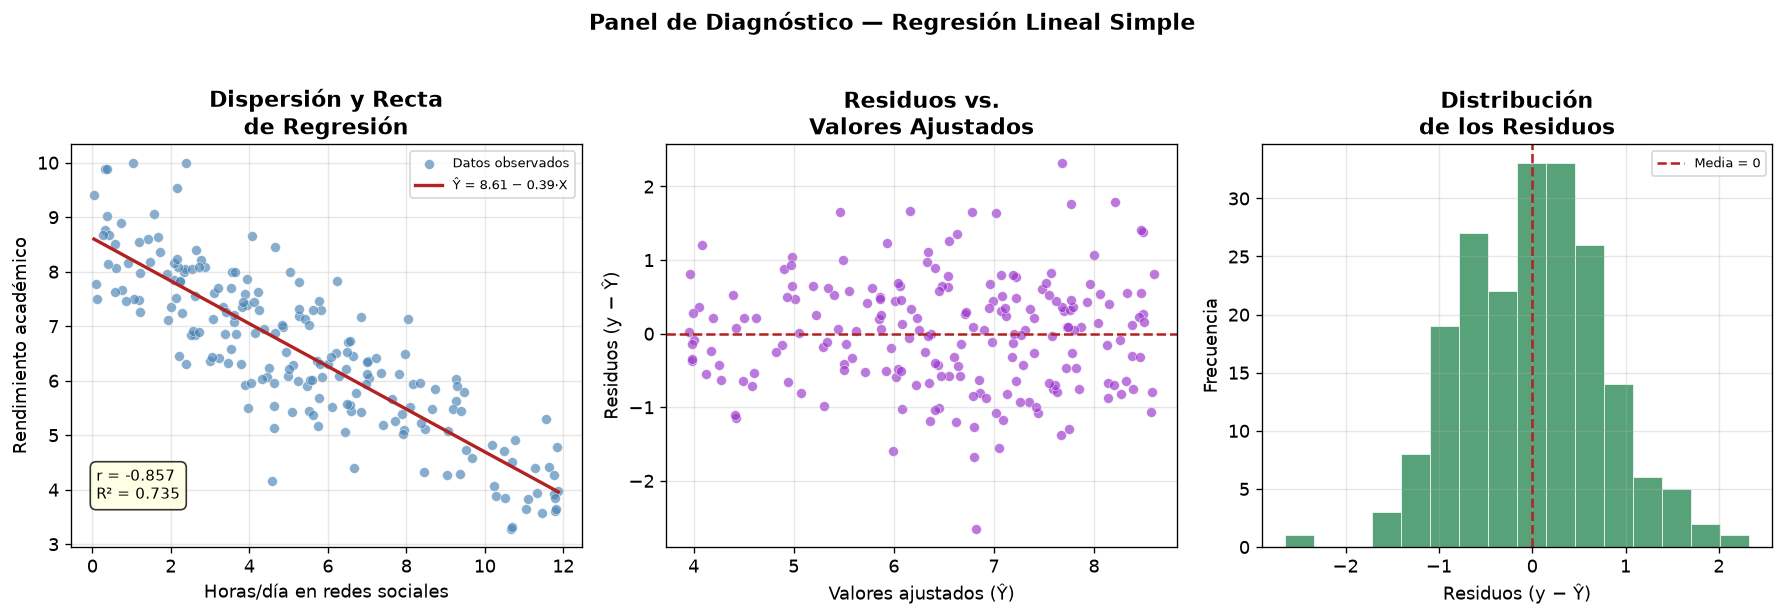

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# PANEL DE SÍNTESIS: Dispersión + Residuos + Distribución de residuos
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Panel 1: Dispersión + recta ──────────────────────────────────────────────
ax1 = axes[0]
ax1.scatter(x, y, color='steelblue', alpha=0.65, s=35, edgecolors='white',
            linewidths=0.4, label='Datos observados')
ax1.plot(x_linea, y_linea, color='firebrick', linewidth=2,
         label=f'Ŷ = {beta_0:.2f} − {abs(beta_1):.2f}·X')
ax1.set_title('Dispersión y Recta\nde Regresión', fontweight='bold')
ax1.set_xlabel('Horas/día en redes sociales')
ax1.set_ylabel('Rendimiento académico')
ax1.legend(fontsize=8)
ax1.text(0.05, 0.12, f'r = {r:.3f}\nR² = {R2:.3f}',
         transform=ax1.transAxes, fontsize=9,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

# ── Panel 2: Residuos vs. valores ajustados ──────────────────────────────────
ax2 = axes[1]
ax2.scatter(y_pred, residuos, color='darkorchid', alpha=0.65, s=35,
            edgecolors='white', linewidths=0.4)
ax2.axhline(0, color='firebrick', linewidth=1.5, linestyle='--')
ax2.set_title('Residuos vs.\nValores Ajustados', fontweight='bold')
ax2.set_xlabel('Valores ajustados (Ŷ)')
ax2.set_ylabel('Residuos (y − Ŷ)')

# ── Panel 3: Histograma de residuos ──────────────────────────────────────────
ax3 = axes[2]
ax3.hist(residuos, bins=16, color='seagreen', edgecolor='white',
         linewidth=0.5, alpha=0.80)
ax3.axvline(0, color='firebrick', linewidth=1.5, linestyle='--', label='Media = 0')
ax3.set_title('Distribución\nde los Residuos', fontweight='bold')
ax3.set_xlabel('Residuos (y − Ŷ)')
ax3.set_ylabel('Frecuencia')
ax3.legend(fontsize=8)

plt.suptitle('Panel de Diagnóstico — Regresión Lineal Simple', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## Resumen de Resultados — Quinta Etapa

| Indicador | Valor | Interpretación |
|---|---|---|
| **Ecuación de regresión** | $\hat{Y} = 8.50 - 0.38 \cdot X$ | Por cada hora más en redes, la nota cae ~0.38 pts. |
| **Ordenada al origen ($\beta_0$)** | $\approx 8.50$ | Nota esperada si $X = 0$ horas/día |
| **Pendiente ($\beta_1$)** | $\approx -0.38$ | Relación negativa entre uso y desempeño |
| **Coeficiente de correlación ($r$)** | $\approx -0.86$ | Correlación **muy fuerte** y negativa |
| **Coeficiente de determinación ($R^2$)** | $\approx 0.74$ | El modelo explica el **74%** de la variabilidad de $Y$ |

### Conclusión de la Etapa

El análisis estadístico confirma la existencia de una **asociación lineal negativa muy fuerte** entre el uso diario de redes sociales y el rendimiento académico en la muestra estudiada. El modelo de regresión lineal simple construido resulta adecuado para describir y cuantificar esta relación, y constituye una herramienta valiosa para el diseño de estrategias de bienestar digital en el ámbito educativo.

---
*Instituto Politécnico Formosa — Trabajo Práctico Integrador: Bienestar Digital*
